# Resultados do AutoML — qual ponto de operação escolher?

Analisa a grade de configurações testadas pelo `scripts/automl_clearml.py`.

**Para usar com a task do ClearML:** ponha o ID da task na célula abaixo (`TASK_ID`).
Enquanto a task não terminar, o notebook cai no CSV local e a leitura é a mesma.

A pergunta que o notebook responde: **quanto de falso positivo custa cada evento
detectado** — e qual configuração entregar para a operação.

In [1]:
# ============================================================
# CONFIGURE AQUI
TASK_ID = "61b6b109896d4b618fd975216d06c25c"   # automl-fp-first-full, alvo CORRIGIDO:
#   8 eventos por varredura, baseline em horas, 4 sinais, veto de sensor (20.736 configs)
CSV_LOCAL = "../automl_out/resultados_61b6b109.parquet"   # só se a task não tiver o artefato
TETO_FP = 1.0           # teto de falso positivo/mês usado na busca
# ============================================================

import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, VERM, VERD, LARJ, CINZA, TINTA = "#2a78d6", "#e34948", "#008300", "#eb6834", "#8b9899", "#0b0b0b"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eeeeee", "font.size": 11,
                     "figure.dpi": 110})

def carregar(task_id, csv_local):
    """Puxa o artefato da task; se não houver, usa o CSV local."""
    if task_id:
        from clearml import Task
        tarefa = Task.get_task(task_id=task_id)
        print(f"task '{tarefa.name}' | status={tarefa.get_status()}")
        artefatos = tarefa.artifacts
        if "automl_results" in artefatos:
            return artefatos["automl_results"].get(), f"ClearML {task_id[:8]}"
        print("  artefato 'automl_results' ainda não publicado — usando CSV local")
    return pd.read_parquet(csv_local), "CSV local"

res, origem = carregar(TASK_ID, CSV_LOCAL)
res["aprovado"] = res["fp_por_mes"] <= TETO_FP

# o limiar pode ser um número (uniforme) ou uma tupla por família
def limiar_str(v):
    return str(v).replace("(", "").replace(")", "").replace(" ", "")
res["limiar"] = res["trial.threshold"].map(limiar_str)

DIMENSOES = [c for c in ["trial.model", "trial.grid", "trial.baseline_hours",
                         "trial.baseline_mode", "trial.exclude_days", "trial.exclude_alarm_h",
                         "trial.min_alert", "trial.ewma", "trial.sustain",
                         "trial.confirm"] if c in res]
COLS_EVENTO = [c for c in res.columns if c.startswith("leads.")]

print(f"\nfonte: {origem} | {len(res):,} configurações testadas")
print(f"detectam ao menos 1 evento: {(res.eventos_detectados > 0).sum():,}")
print(f"respeitam o teto de {TETO_FP} FP/mês: {int(res.aprovado.sum()):,}")

task 'automl-fp-first-full' | status=completed

fonte: ClearML 61b6b109 | 31,104 configurações testadas
detectam ao menos 1 evento: 19,779
respeitam o teto de 1.0 FP/mês: 11,395


---
## 1. A fronteira: quanto custa cada evento detectado

Cada ponto é uma configuração. Queremos o canto **superior esquerdo** (detecta muito,
alarma falso pouco).

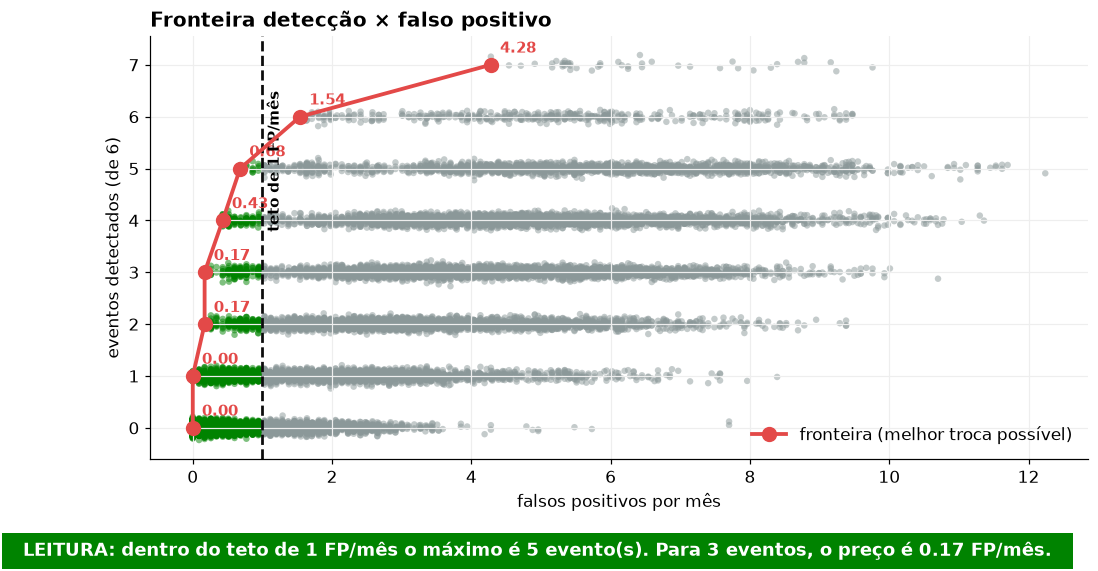

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
jitter = np.random.default_rng(0).normal(0, 0.06, len(res))
cores = np.where(res["aprovado"], VERD, CINZA)
ax.scatter(res["fp_por_mes"], res["eventos_detectados"] + jitter, s=18, c=cores,
           alpha=0.5, linewidth=0)

# fronteira: menor FP para cada nº de eventos
fronteira = res.groupby("eventos_detectados")["fp_por_mes"].min().reset_index()
ax.plot(fronteira["fp_por_mes"], fronteira["eventos_detectados"], color=VERM, lw=2.5,
        marker="o", ms=9, zorder=5, label="fronteira (melhor troca possível)")
for _, linha in fronteira.iterrows():
    ax.annotate(f"{linha.fp_por_mes:.2f}", xy=(linha.fp_por_mes, linha.eventos_detectados),
                xytext=(6, 8), textcoords="offset points", fontsize=10,
                color=VERM, fontweight="bold")

ax.axvline(TETO_FP, color=TINTA, ls="--", lw=1.8)
ax.text(TETO_FP + 0.06, res["eventos_detectados"].max() * 0.55,
        f"teto de {TETO_FP:.0f} FP/mês", rotation=90, fontsize=10, fontweight="bold")
ax.set_xlabel("falsos positivos por mês"); ax.set_ylabel("eventos detectados (de 6)")
ax.set_yticks(range(0, int(res["eventos_detectados"].max()) + 1))
ax.legend(frameon=False, loc="lower right")
ax.set_title("Fronteira detecção × falso positivo", fontweight="bold", loc="left")

melhor_no_teto = int(res.loc[res.aprovado, "eventos_detectados"].max()) if res.aprovado.any() else 0
fp_para_3 = fronteira.loc[fronteira.eventos_detectados >= 3, "fp_por_mes"]
cor = VERD if melhor_no_teto >= 3 else VERM
texto = (f"dentro do teto de {TETO_FP:.0f} FP/mês o máximo é {melhor_no_teto} evento(s). "
         + (f"Para 3 eventos, o preço é {fp_para_3.min():.2f} FP/mês."
            if len(fp_para_3) else ""))
fig.text(0.01, -0.04, f"  LEITURA: {texto}  ", fontsize=11.5, color="white",
         fontweight="bold", va="top", bbox=dict(facecolor=cor, edgecolor="none", pad=6))
plt.show()

---
## 1b. A limpeza do baseline valeu a pena?

Esta rodada testou remover do treino os dias que antecedem cada falha conhecida
(0, 3, 7 ou 10 dias). A tabela mostra o **menor falso positivo** para cada nível de
detecção, em cada opção de limpeza — quanto menor, melhor.

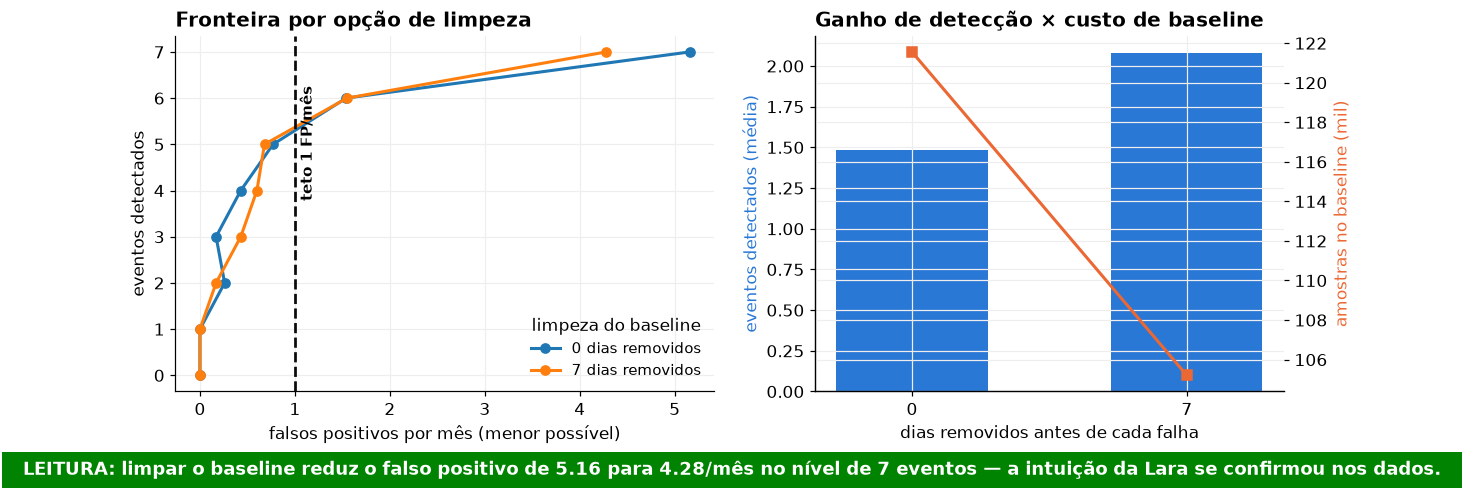

In [3]:
if "trial.exclude_days" in res:
    fronteiras = res.pivot_table(index="eventos_detectados", columns="trial.exclude_days",
                                 values="fp_por_mes", aggfunc="min")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2),
                                   gridspec_kw={"width_ratios": [1.15, 1]})

    for coluna in fronteiras.columns:
        serie = fronteiras[coluna].dropna()
        ax1.plot(serie.values, serie.index, marker="o", ms=6, lw=2,
                 label=f"{coluna} dias removidos")
    ax1.axvline(TETO_FP, color=TINTA, ls="--", lw=1.8)
    ax1.text(TETO_FP * 1.05, fronteiras.index.max() * 0.55, f"teto {TETO_FP:.0f} FP/mês",
             rotation=90, fontsize=9.5, fontweight="bold")
    ax1.set_xlabel("falsos positivos por mês (menor possível)")
    ax1.set_ylabel("eventos detectados")
    ax1.set_yticks(fronteiras.index)
    ax1.legend(frameon=False, fontsize=9.5, title="limpeza do baseline")
    ax1.set_title("Fronteira por opção de limpeza", fontweight="bold", loc="left")

    resumo = res.groupby("trial.exclude_days").agg(
        det=("eventos_detectados", "mean"), base=("baseline_amostras", "mean"))
    eixo_b = ax2.twinx()
    ax2.bar([str(i) for i in resumo.index], resumo["det"], color=AZUL, width=0.55)
    eixo_b.plot([str(i) for i in resumo.index], resumo["base"] / 1000, color=LARJ,
                marker="s", lw=2)
    ax2.set_ylabel("eventos detectados (média)", color=AZUL)
    eixo_b.set_ylabel("amostras no baseline (mil)", color=LARJ)
    eixo_b.spines["top"].set_visible(False)
    ax2.set_xlabel("dias removidos antes de cada falha")
    ax2.set_title("Ganho de detecção × custo de baseline", fontweight="bold", loc="left")

    sem, com = fronteiras.get(0), fronteiras.drop(columns=[0], errors="ignore")
    ganhos = []
    for n_ev in fronteiras.index:
        if n_ev == 0 or sem is None or pd.isna(sem.get(n_ev)):
            continue
        melhor = com.loc[n_ev].min() if n_ev in com.index else np.nan
        if pd.notna(melhor) and melhor < sem[n_ev]:
            ganhos.append((n_ev, sem[n_ev], melhor))
    if ganhos:
        n_ev, antes, depois = max(ganhos, key=lambda g: g[1] - g[2])
        texto = (f"limpar o baseline reduz o falso positivo de {antes:.2f} para {depois:.2f}/mês "
                 f"no nível de {n_ev} eventos — a intuição da Lara se confirmou nos dados.")
        cor = VERD
    else:
        texto = "a limpeza não melhorou a fronteira nesta grade."
        cor = LARJ
    fig.text(0.01, -0.04, f"  LEITURA: {texto}  ", fontsize=11.5, color="white",
             fontweight="bold", va="top", bbox=dict(facecolor=cor, edgecolor="none", pad=6))
    plt.show()
else:
    print("esta rodada não testou limpeza de baseline (coluna trial.exclude_days ausente)")

---
## 2. Que decisão importa mais?

Para cada dimensão da busca, quanto ela move a detecção e o falso positivo. Dimensão
"chata" (barras iguais) pode ser fixada; dimensão que separa muito é onde vale investir.

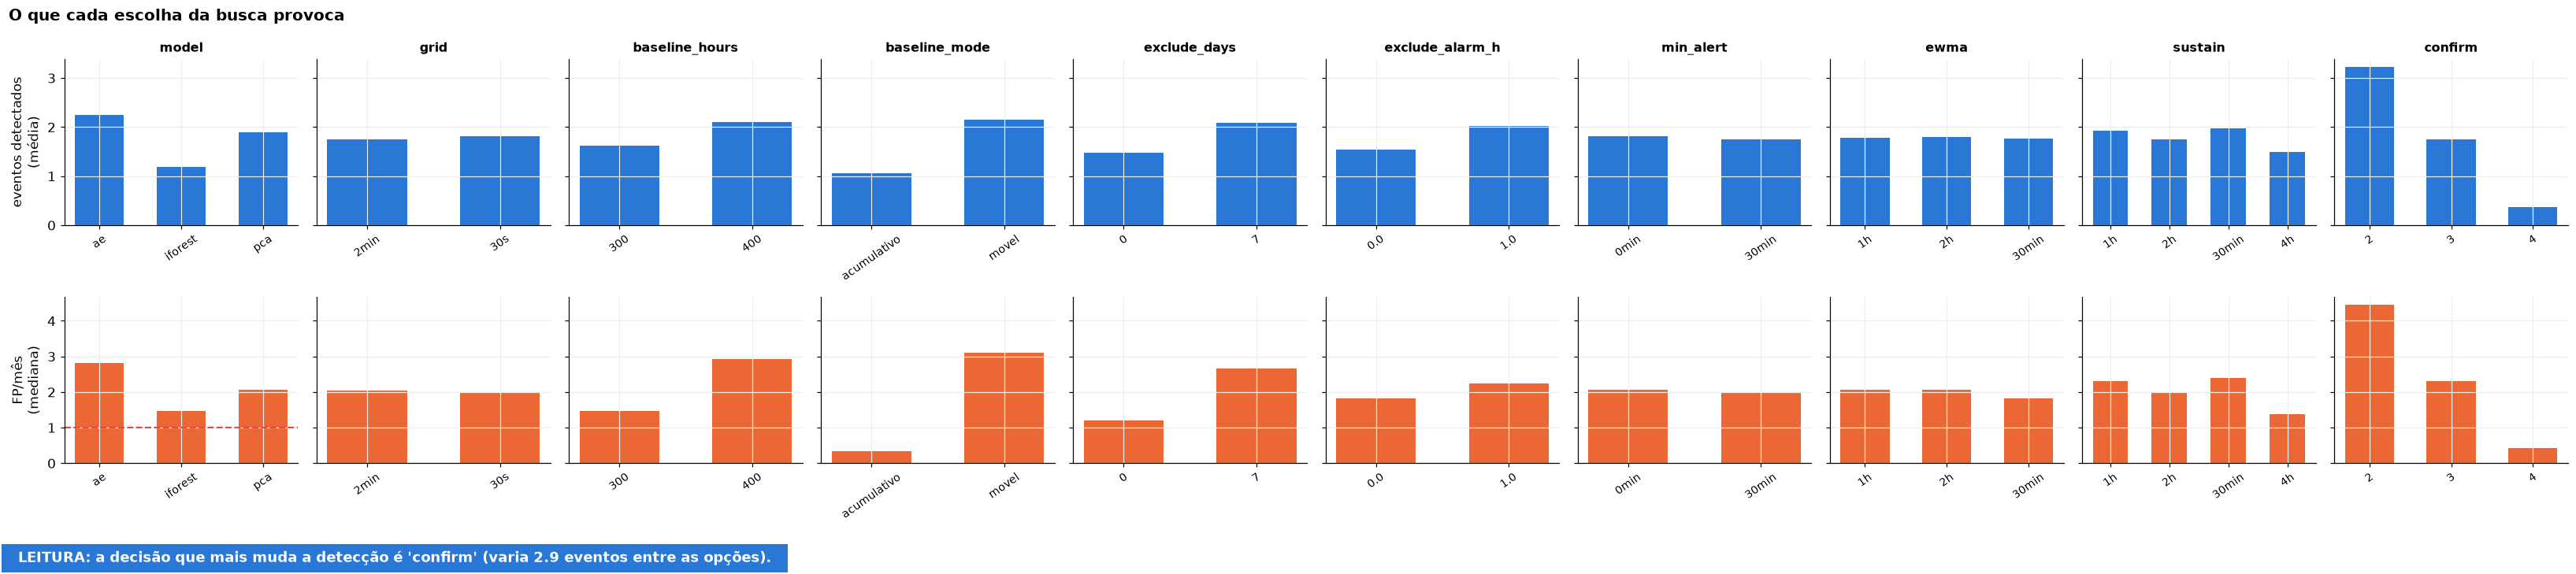

In [4]:
fig, axes = plt.subplots(2, len(DIMENSOES), figsize=(3.0 * len(DIMENSOES), 6.2),
                         sharey="row")
for coluna, dim in enumerate(DIMENSOES):
    agrupado = res.groupby(dim).agg(det=("eventos_detectados", "mean"),
                                    fp=("fp_por_mes", "median"))
    nomes = [str(i) for i in agrupado.index]
    axes[0, coluna].bar(nomes, agrupado["det"], color=AZUL, width=0.6)
    axes[1, coluna].bar(nomes, agrupado["fp"], color=LARJ, width=0.6)
    axes[0, coluna].set_title(dim.replace("trial.", ""), fontsize=10.5, fontweight="bold")
    for eixo in (axes[0, coluna], axes[1, coluna]):
        eixo.tick_params(axis="x", rotation=35, labelsize=9)
axes[1, 0].axhline(TETO_FP, color=VERM, ls="--", lw=1.4)
axes[0, 0].set_ylabel("eventos detectados\n(média)")
axes[1, 0].set_ylabel("FP/mês\n(mediana)")
fig.suptitle("O que cada escolha da busca provoca", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout()

variacao = {d: float(res.groupby(d)["eventos_detectados"].mean().max()
                     - res.groupby(d)["eventos_detectados"].mean().min())
            for d in DIMENSOES}
mais_forte = max(variacao, key=variacao.get)
fig.text(0.01, -0.03, f"  LEITURA: a decisão que mais muda a detecção é "
         f"'{mais_forte.replace('trial.','')}' "
         f"(varia {variacao[mais_forte]:.1f} eventos entre as opções).  ",
         fontsize=11.5, color="white", fontweight="bold", va="top",
         bbox=dict(facecolor=AZUL, edgecolor="none", pad=6))
plt.show()

---
## 3. Quais falhas são fáceis e quais são difíceis

Fração das configurações que conseguiu antecipar cada evento. Evento que quase ninguém
pega é o que precisa de **sinal novo**, não de ajuste de limiar.

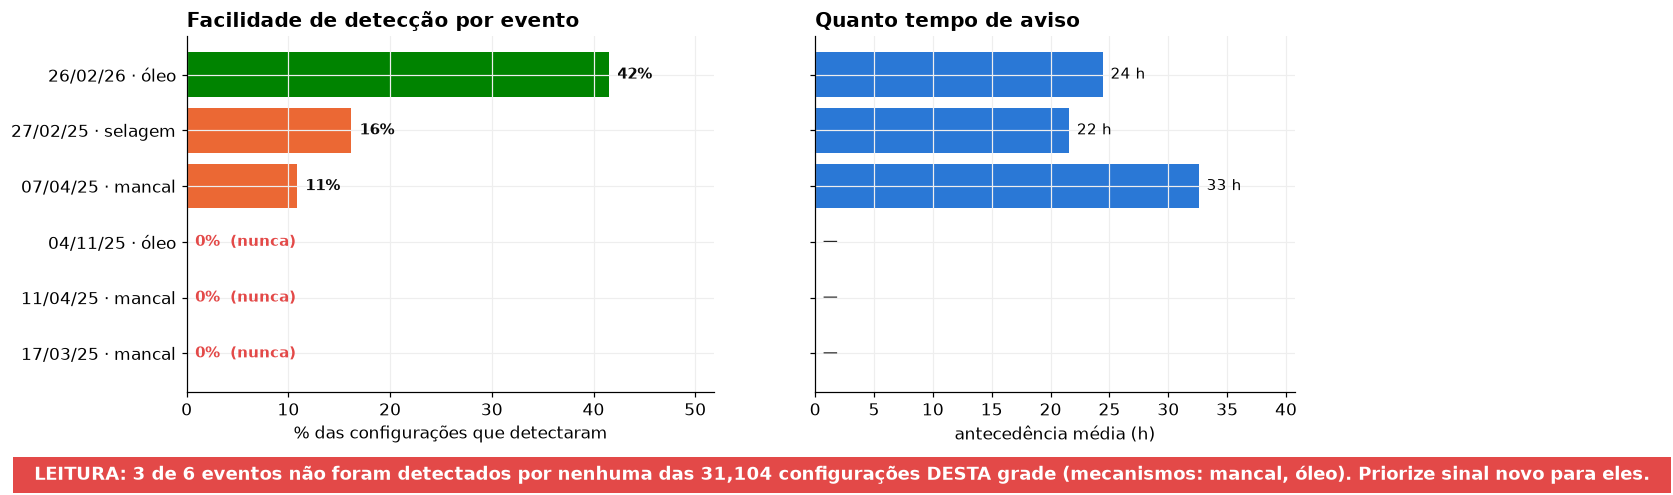

In [5]:
# Os 6 eventos físicos do período, com o mecanismo. Precisa ser a lista completa:
# as colunas 'leads.*' só existem para eventos que ALGUMA configuração detectou,
# então quem nunca foi detectado desapareceria do gráfico.
EVENTOS = [("2025-02-27 08:38", "selagem"), ("2025-03-17 18:15", "mancal"),
           ("2025-04-07 21:18", "mancal"), ("2025-04-11 17:03", "mancal"),
           ("2025-11-04 06:24", "óleo"),   ("2026-02-26 15:34", "óleo")]

taxa, lead_medio, rotulos = {}, {}, {}
for quando, mecanismo in EVENTOS:
    coluna = next((c for c in COLS_EVENTO if c.replace("leads.", "").startswith(quando)), None)
    chave = f"{pd.Timestamp(quando):%d/%m/%y} · {mecanismo}"
    taxa[chave] = res[coluna].notna().mean() * 100 if coluna else 0.0
    lead_medio[chave] = res[coluna].mean() if coluna else np.nan
    rotulos[chave] = mecanismo
ordem = sorted(taxa, key=taxa.get)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
cores = [VERD if taxa[k] > 30 else (LARJ if taxa[k] > 5 else VERM) for k in ordem]
ax1.barh(ordem, [taxa[k] for k in ordem], color=cores)
ax1.set_xlim(0, max(max(taxa.values()) * 1.25, 10))
for i, k in enumerate(ordem):
    ax1.text(taxa[k] + max(taxa.values()) * 0.02, i,
             f"{taxa[k]:.0f}%" + ("  (nunca)" if taxa[k] == 0 else ""),
             va="center", fontsize=10, fontweight="bold",
             color=VERM if taxa[k] == 0 else TINTA)
ax1.set_xlabel("% das configurações que detectaram")
ax1.set_title("Facilidade de detecção por evento", fontweight="bold", loc="left")

leads_plot = [0 if np.isnan(lead_medio[k]) else lead_medio[k] for k in ordem]
ax2.barh(ordem, leads_plot, color=[CINZA if v == 0 else AZUL for v in leads_plot])
ax2.set_xlim(0, max(max(leads_plot) * 1.25, 5))
for i, (k, v) in enumerate(zip(ordem, leads_plot)):
    ax2.text(v + max(leads_plot) * 0.02, i, "—" if v == 0 else f"{v:.0f} h",
             va="center", fontsize=10)
ax2.set_xlabel("antecedência média (h)")
ax2.set_title("Quanto tempo de aviso", fontweight="bold", loc="left")
ax2.set_yticklabels([])

nunca = [k for k in taxa if taxa[k] == 0]
mecanismos_cegos = sorted({rotulos[k] for k in nunca})
fig.text(0.01, -0.05,
         f"  LEITURA: {len(nunca)} de {len(EVENTOS)} eventos não foram detectados por "
         f"nenhuma das {len(res):,} configurações DESTA grade"
         + (f" (mecanismos: {', '.join(mecanismos_cegos)}). " if nunca else ". ")
         + "Priorize sinal novo para eles.  ",
         fontsize=11.5, color="white", fontweight="bold", va="top",
         bbox=dict(facecolor=VERM if nunca else VERD, edgecolor="none", pad=6))
plt.show()

> **Cuidado ao ler "não detectado":** vale para as configurações **desta** grade. Uma grade
> mais permissiva detecta mais eventos — na grade `balanced`, com limiar no p99 e
> IsolationForest, chegam a 5 de 6 — mas ao custo de ~6 falsos positivos/mês. O que a
> figura mostra é quais eventos exigem limiar frouxo (logo, sinal melhor) para aparecer.

---
## 4. Mapa limiar × persistência

Onde fica a região boa: limiar mais alto e alarme mais persistente reduzem o falso
positivo, mas em algum ponto matam a detecção. O mapa mostra os dois efeitos lado a lado.

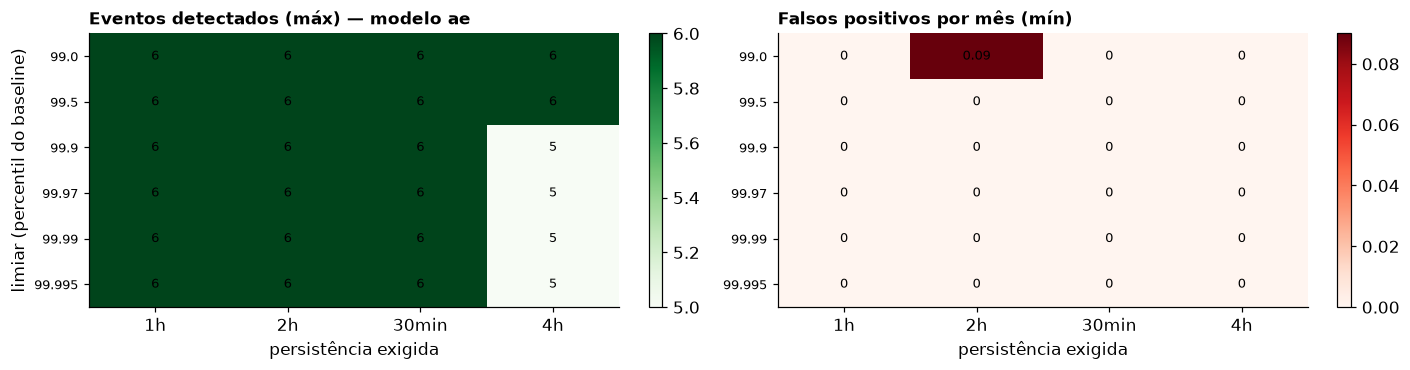

In [6]:
melhor_modelo = (res.groupby("trial.model")["eventos_detectados"].mean().idxmax()
                 if "trial.model" in res else None)
sub = res[res["trial.model"] == melhor_modelo] if melhor_modelo else res

pivo_det = sub.pivot_table(index="limiar", columns="trial.sustain",
                           values="eventos_detectados", aggfunc="max")
pivo_fp = sub.pivot_table(index="limiar", columns="trial.sustain",
                          values="fp_por_mes", aggfunc="min")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, max(3.5, 0.32 * len(pivo_det))))
for eixo, dados, titulo, mapa in [
        (ax1, pivo_det, f"Eventos detectados (máx) — modelo {melhor_modelo}", "Greens"),
        (ax2, pivo_fp, "Falsos positivos por mês (mín)", "Reds")]:
    imagem = eixo.imshow(dados.values, aspect="auto", cmap=mapa)
    eixo.set_xticks(range(len(dados.columns))); eixo.set_xticklabels(dados.columns)
    eixo.set_yticks(range(len(dados.index)))
    eixo.set_yticklabels(dados.index, fontsize=8.5)
    eixo.set_xlabel("persistência exigida"); eixo.set_title(titulo, fontweight="bold",
                                                            loc="left", fontsize=11)
    eixo.grid(False)
    for i in range(dados.shape[0]):
        for j in range(dados.shape[1]):
            valor = dados.values[i, j]
            if not np.isnan(valor):
                eixo.text(j, i, f"{valor:.2f}".rstrip("0").rstrip(".") if mapa == "Reds"
                          else f"{valor:.0f}", ha="center", va="center", fontsize=8.5)
    fig.colorbar(imagem, ax=eixo, fraction=0.046)
ax1.set_ylabel("limiar (percentil do baseline)")
fig.tight_layout()
plt.show()

---
## 5. As configurações candidatas

Duas listas: as melhores **dentro** do teto de falso positivo, e as melhores permitindo
um teto mais folgado — porque a fronteira mostra que essa é a decisão real a tomar com
a operação.

In [7]:
COLS = DIMENSOES + ["limiar", "eventos_detectados", "lead_medio_h", "fp_por_mes"]

def ranquear(dados, n=5):
    return (dados.sort_values(["eventos_detectados", "lead_medio_h"],
                              ascending=[False, False]).head(n)[COLS]
            .rename(columns=lambda c: c.replace("trial.", "")))

print(f"=== MELHORES DENTRO DO TETO DE {TETO_FP} FP/MÊS ===")
dentro = res[res.aprovado]
print(ranquear(dentro).to_string(index=False) if len(dentro) else "  nenhuma configuração")

for teto in (2.0, 3.0):
    folga = res[res.fp_por_mes <= teto]
    print(f"\n=== MELHORES COM TETO DE {teto} FP/MÊS ===")
    print(ranquear(folga, 3).to_string(index=False) if len(folga) else "  nenhuma")

=== MELHORES DENTRO DO TETO DE 1.0 FP/MÊS ===
model grid  baseline_hours baseline_mode  exclude_days  exclude_alarm_h min_alert  ewma sustain  confirm limiar  eventos_detectados  lead_medio_h  fp_por_mes
   ae 2min             300   acumulativo             0              1.0      0min    2h      4h        2 99.995                   5          21.4        0.94
   ae 2min             300   acumulativo             0              1.0     30min    2h      4h        2 99.995                   5          20.9        0.94
  pca 2min             300   acumulativo             0              1.0      0min    2h   30min        2   99.9                   5          17.9        0.77
   ae  30s             300   acumulativo             7              0.0      0min 30min   30min        2 99.995                   5          11.2        0.95
  pca 2min             300   acumulativo             0              1.0     30min    1h      1h        2   99.9                   5          11.0        0.94

=== M

---
## Como ler tudo isso

1. **Se a fronteira mostra que o teto atual só é atingível com 0 detecções**, o problema
   não é de ajuste — é de sinal. Os próximos ganhos vêm de sinal novo (selagem dedicada,
   veto de falha de sensor, resíduo por carga), não de mais busca.
2. **O evento mais difícil** (figura 3) diz qual sinal criar primeiro.
3. **A decisão de negócio** é o teto de falso positivo: a tabela da seção 5 mostra o que
   se ganha em detecção ao aceitar 2 ou 3 alarmes falsos por mês. Isso é conversa com a
   operação, não escolha técnica.